In [46]:
# Initialization
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Bài 3.26

In [47]:
# Bai 3.26
def grad(x) :
 return (2*x - 4)

def func(x) :
 return (x**2 - 4*x + 5)

def GD(x0, eta = 0.2, iter = 4, strict = True) :
  x = [x0]
  print(f"Initial f(x): {func(x0):.4f} | x0: {x0} | learning_rate: {eta}")

  for it in range(iter) :
    x_new = x[-1] - eta*grad(x[-1])
    if (abs(grad(x_new)) < 1e-3 ) and (strict == False):
      break
    x.append(x_new)

    if (strict == True) :
      print(f"Iteration {it+1}: {func(x[-1]):.4f}")
  return (x, it)

(x1, it1) = GD(5, .2, 4, True)
print(f"Result: x: {x1[-1]:.4f} | f(x): {func(x1[-1]):.4f} | Iterations: {it1+1}")
print(f"Nhận xét: hội tụ toàn cục về cực tiểu x* = 2")

Initial f(x): 10.0000 | x0: 5 | learning_rate: 0.2
Iteration 1: 4.2400
Iteration 2: 2.1664
Iteration 3: 1.4199
Iteration 4: 1.1512
Result: x: 2.3888 | f(x): 1.1512 | Iterations: 4
Nhận xét: hội tụ toàn cục về cực tiểu x* = 2


# Bài 3.27

In [48]:
# Bai 3.27
w = np.array([1, 2, -10])
x = np.array([3, 4, 1])
y_true = -1

wTx = np.dot(w, x)
print(f"1. w^T * x = {wTx}")
# Cau 1: w.T @ x = [1*3 + 2*4 - 10*1] = [1]

y_pred = 1 if wTx >= 0 else -1
print(f"2. Predicted y: {y_pred} | True y: {y_true}")
# Cau 2: sgn(wTx) = sgn(1) = 1

is_misclassified = (y_pred != y_true)
print(f"3. Is misclassified?: {is_misclassified}")
# Cau 3: y_true = -1; y_pred = 1
# ==> y_true != y_pred
# ==> Misclassified

1. w^T * x = 1
2. Predicted y: 1 | True y: -1
3. Is misclassified?: True


# Bài 3.28

In [49]:
# Bai 3.28
w = np.array([-2, 1, 0])
x = np.array([2, 3, 1])
y = 1

def perceptron_update(w, x, y, eta = 1):
    if y * np.dot(w, x) <= 0:
        w += y * x * eta
    return w

wTx = np.dot(w, x)
print(f"1. w^T * x = {wTx}")
# wTx = -1

y_pred1 = 1 if wTx >= 0 else -1
print(f"2. Predicted y: {y_pred1} | True y: {y}")
# y_pred = sgn(wTx) = -1

is_misclassified = (y_pred1 != y)
print(f"3. Is misclassified?: {is_misclassified}")
# y_true = 1 != y_pred
# ==> Misclassified

w_updated = perceptron_update(w, x, y)
print(f"4. New w: {w_updated}")
# Update w: w_new = w + eta*y*x = (0, 4, 1)

wTx_updated = np.dot(w_updated, x)
print(f"5. New w^T * x = {wTx_updated}")

1. w^T * x = -1
2. Predicted y: -1 | True y: 1
3. Is misclassified?: True
4. New w: [0 4 1]
5. New w^T * x = 13


# Bài 3.29

Total: 200
Passed: 117 | Failed: 83

Accuracy: 92.50%

Student A (15h study time, 90% attendance): Passed
Student B (3h study time, 60% attendance): Failed
--- EXAMPLE ---
   Study_hours  Attendance   Label
0        14.95       63.96  Passed
1        15.84       91.55  Passed
2        16.66       96.82  Passed
3        16.80       99.29  Passed
4        19.22       52.19  Passed
5        16.78       69.38  Passed
6         2.02       77.23  Failed
7         2.02       65.67  Failed
8        12.40       83.60  Passed
9        18.52       57.80  Passed
------------------------------------



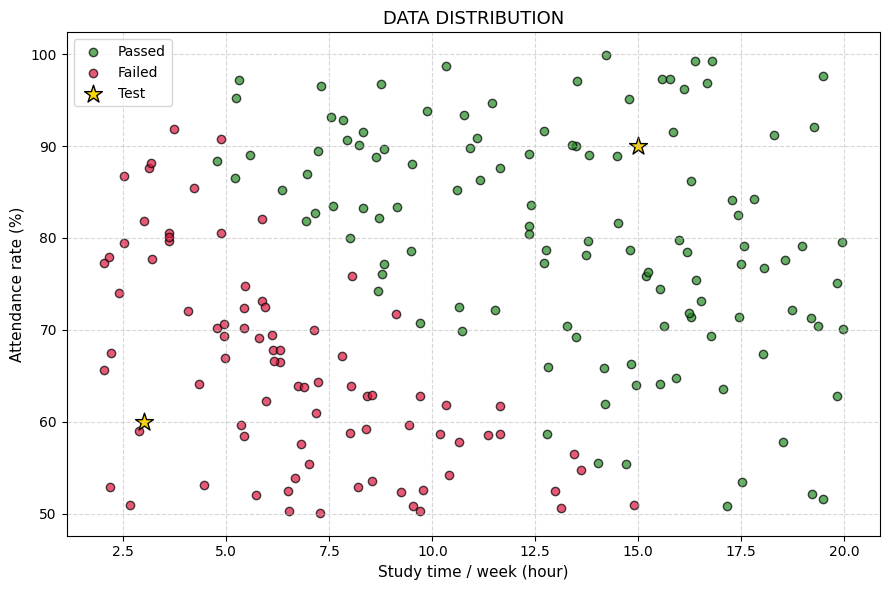

In [50]:
# Bai 3.29
np.random.seed(3206)
n_samples = 200

# Fake data
study_hours = np.random.uniform(2, 20, n_samples)
attendance = np.random.uniform(50, 100, n_samples)
X = np.column_stack((study_hours, attendance))
noise = np.random.normal(0, 3, n_samples)
score = 3 * study_hours + 0.8 * attendance - 85 + noise
y = np.where(score >= 0, 1, 0)

print(f"Total: {n_samples}")
print(f"Passed: {np.sum(y == 1)} | Failed: {np.sum(y == 0)}\n")

# Train
## Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Training
model = Perceptron(eta0=0.1, max_iter=100, random_state=3206)
model.fit(X_train_scaled, y_train)

## Scoring
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# Testing
new_students = np.array([
    [15, 90],
    [3, 60]
])

new_students_scaled = scaler.transform(new_students)
results = model.predict(new_students_scaled)

labels = {1: "Passed", 0: "Failed"}
print(f"Student A (15h study time, 90% attendance): {labels[results[0]]}")
print(f"Student B (3h study time, 60% attendance): {labels[results[1]]}")


# ==========================================
# Visualization
# ==========================================
df = pd.DataFrame(X, columns=['Study_hours', 'Attendance'])
df['Label'] = ['Passed' if label == 1 else 'Failed' for label in y]
print("--- EXAMPLE ---")
print(df.head(10).round(2))
print("------------------------------------\n")
plt.figure(figsize=(9, 6))
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='forestgreen', label='Passed', alpha=0.7, edgecolors='k')
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='crimson', label='Failed', alpha=0.7, edgecolors='k')
plt.scatter(new_students[:, 0], new_students[:, 1], color='gold', s=180, marker='*', edgecolors='black', label='Test')
plt.title("DATA DISTRIBUTION", fontsize=13)
plt.xlabel("Study time / week (hour)", fontsize=11)
plt.ylabel("Attendance rate (%)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Bài 3.30

Dataset shape: (178, 13)
Number of features: 13
Class distribution: Cultivar 1 = 59, Others = 119

Optimal Hyperparameters:
{'alpha': 1e-05, 'class_weight': 'balanced', 'early_stopping': True, 'eta0': 0.01, 'max_iter': 1000, 'n_iter_no_change': 5, 'penalty': 'l2'}

             TEST SET EVALUATION             
Accuracy  : 98.15%
Precision : 100.00%
Recall    : 94.44%
F1-Score  : 97.14%
---------------------------------------------

Classification Report:

                 precision    recall  f1-score   support

Other Cultivars       0.97      1.00      0.99        36
     Cultivar 1       1.00      0.94      0.97        18

       accuracy                           0.98        54
      macro avg       0.99      0.97      0.98        54
   weighted avg       0.98      0.98      0.98        54



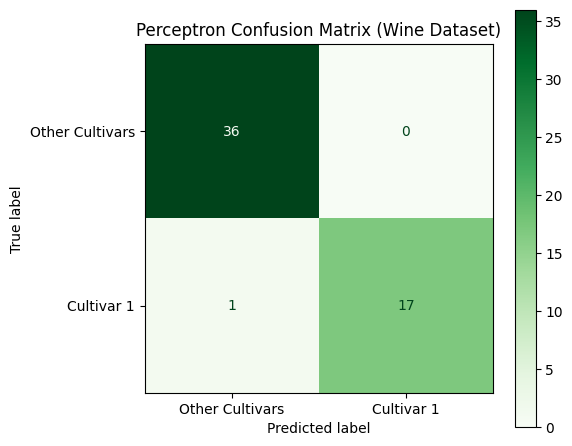

In [51]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -------------------------------------------------------------
# 1. Load Dataset & Format for Binary Classification
# -------------------------------------------------------------
wine = load_wine()
X = wine.data

# Transform into binary target:
# 1 = Class 0 (Cultivar 1), 0 = Other cultivars (Class 1 & 2)
y = (wine.target == 0).astype(int)
target_names = ['Other Cultivars', 'Cultivar 1']

print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Class distribution: Cultivar 1 = {np.sum(y == 1)}, Others = {np.sum(y == 0)}\n")

# -------------------------------------------------------------
# 2. Stratified Train/Test Split
# -------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=3206, stratify=y
)

# -------------------------------------------------------------
# 3. Feature Scaling
# -------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------------------------------------
# 4. Hyperparameter Tuning with GridSearchCV
# -------------------------------------------------------------
param_grid = {
    'penalty': ['l2', 'l1', 'elasticnet', None],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'eta0': [0.01, 0.1, 0.5, 1.0],
    'max_iter': [1000, 2000],
    'class_weight': ['balanced', None],
    'early_stopping': [True],
    'n_iter_no_change': [5]
}

base_perceptron = Perceptron(random_state=3206, tol=1e-3)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=3206)

grid_search = GridSearchCV(
    estimator=base_perceptron,
    param_grid=param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"Optimal Hyperparameters:\n{grid_search.best_params_}\n")

# -------------------------------------------------------------
# 5. Model Evaluation
# -------------------------------------------------------------
y_pred = best_model.predict(X_test_scaled)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 45)
print("             TEST SET EVALUATION             ")
print("=" * 45)
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")
print("-" * 45)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

# -------------------------------------------------------------
# 6. Confusion Matrix Visualization
# -------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Greens, values_format='d', ax=ax)
plt.title("Perceptron Confusion Matrix (Wine Dataset)")
plt.grid(False)
plt.tight_layout()
plt.show()